https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing

# Анализ результатов А/Б-тестирования

**Задача исследования**

На основе датасета с действиями пользователей, требуется провести оценку результатов А/Б теста.

**Ход исследования**

Для проведения исследования доступны:

* cookie_cats.csv - данные об активности игроков в мобильной игре.

Перед решением задачи понадобится обзор данных. На этапе предобработки исправим найденные ошибки.

Далее проверим корректность проведения теста и проведем исследовательский анализ.

**Этапы исследования:**
1. Обзор данных
2. Предобработка данных
3. Корректность проведения теста
4. Исследовательский анализ
5. Анализ результатов А/Б тестирования
6. Выводы

In [513]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from tqdm import tqdm

In [7]:
path = '/mnt/c/Users/koles/Downloads/datasets/mobile_games_ab_testing/cookie_cats.csv'
df = pd.read_csv(path)

# 1. Обзор данных

In [15]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [12]:
df.shape

(90189, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [11]:
df.describe(include='all')

,userid,version,sum_gamerounds,retention_1,retention_7
count,9.018900e+04,90189,90189.000000,90189,90189
unique,NaN,2,NaN,2,2
top,NaN,gate_40,NaN,False,False
freq,NaN,45489,NaN,50036,73408
mean,4.998412e+06,NaN,51.872457,NaN,NaN
std,2.883286e+06,NaN,195.050858,NaN,NaN
min,1.160000e+02,NaN,0.000000,NaN,NaN
25%,2.512230e+06,NaN,5.000000,NaN,NaN
50%,4.995815e+06,NaN,16.000000,NaN,NaN
75%,7.496452e+06,NaN,51.000000,NaN,NaN


In [17]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [19]:
df.duplicated().sum()

0

### Вывод

В датасете присутствуют данные:
* об уникальном идентификаторе пользователя
* группа, в которую попал пользователь
* количество пройденых раундов
* ретеншн 1-го дня
* ретеншн 7-го дня

Всего доступно 90189 записей.

Ошибок в данных не обнаружено. Этап предобработки данных можно пропустить.

В колонке `sum_gamerounds` присутствует аномально высокое значение. На этапе исследовательского анализа нужно обратить на это внимание.

# 2. Предобработка данных

# 3. Корректность проведения теста

In [39]:
# проверим, чтобы количество уникальных пользователей
# совпадало с размерностью таблицы

(
    df.userid.nunique(),
    df.shape[0]
)

(90189, 90189)

Количество уникальных пользователей совпадает с размерностью таблицы. Это значит, что каждый пользователь принял участие в тесте один раз.

In [85]:
# количество пользователей в каждой группе

df.version.value_counts(normalize=True)

gate_40    0.504374
gate_30    0.495626
Name: version, dtype: float64

В группе `B` (gate_40) попало на 0.4% больше пользователей, что не язвяется критичным.

In [151]:
# посмотрим на граффик метрики ретеншн во время теста

df['cumcount'] = df.groupby('version').cumcount() + 1

df['retention_1'] = df['retention_1'] * 1
df['retention_7'] = df['retention_7'] * 1

df['retention_rate_1'] = df.groupby('version')['retention_1'].cumsum()
df['retention_rate_7'] = df.groupby('version')['retention_7'].cumsum()

df['retention_rate_1'] = df['retention_rate_1'] / df['cumcount']
df['retention_rate_7'] = df['retention_rate_7'] / df['cumcount']

In [710]:
def retention_plot(day: int=1, index: int=100000) -> None:
    gate_30 = (df[df['version'] == 'gate_30'][f'retention_rate_{day}']
                   .iloc[:index].reset_index(drop=True))
    gate_40 = (df[df['version'] == 'gate_40'][f'retention_rate_{day}']
                   .iloc[:index].reset_index(drop=True))
    
    plt.plot(gate_30, label='gate_30')
    plt.plot(gate_40, label='gate_40')
    
    plt.title(f'Ретеншн {day}-го дня')
    plt.legend()

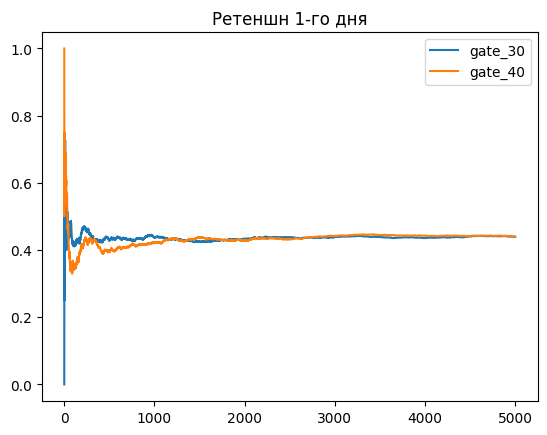

In [711]:
retention_plot(1, 5000)

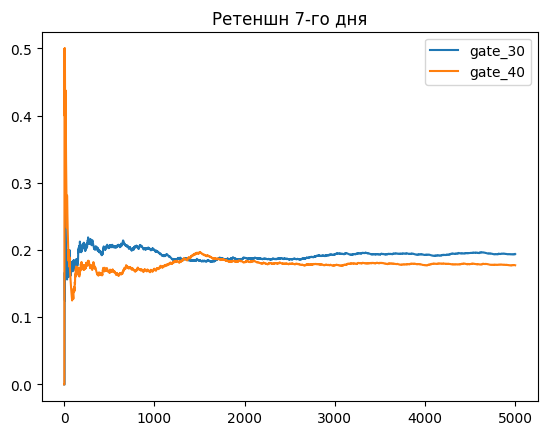

In [712]:
retention_plot(7, 5000)

Примерно за первые 1000 пользователей метрика колеблется, далее выходит на плато и остается стабильной. Ошибок в данных не наблюдается.

### Вывод

1. Количество уникальных пользователей равно количеству записей в таблице. Ни один пользователь не принимал участие в тесте за две группы одновременно.
2. Расспределение по группам примерно одинаковое. В группе `B` (gate_40) попало на 0.4% больше пользователей, что не язвяется критичным.
3. Ошибок в колонке ретеншн не выявлено. 

# 4. Исследовательский анализ

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

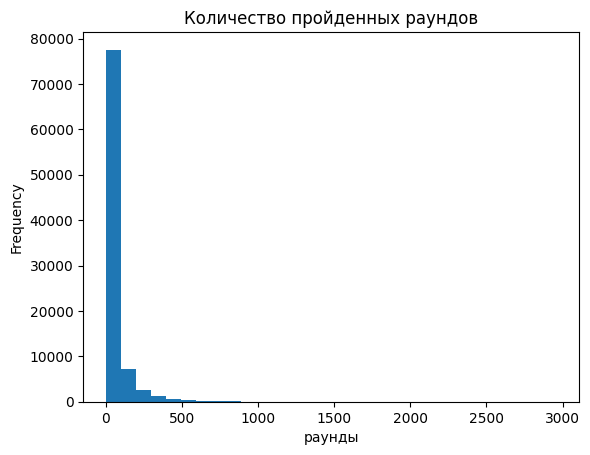

In [713]:
# для исследовательского анализа остается
# одна колонка 'sum_gamerounds', посмотрим
# на нее подробнее

display(df.sum_gamerounds.describe())

df.sum_gamerounds.plot(kind='hist', bins=30)

plt.title('Количество пройденных раундов')
plt.xlabel('раунды')

plt.show();

График не информативный. В данных присутствует выбрасы, количество пройденых раундов = 49854. Посмотрим на количество подобных выбросов.

In [329]:
# посчитаем 0.9999 квантиль и распечатаем 
# данные больше это значения

quantile_9999 = df.sum_gamerounds.quantile(0.9999)

display(quantile_9999, df[df.sum_gamerounds > quantile_9999].shape)

df[df.sum_gamerounds > quantile_9999]

2012.950799999424

(10, 8)

,userid,version,sum_gamerounds,retention_1,retention_7,cumcount,retention_rate_1,retention_rate_7
6536,725080,gate_40,2015,1,1,3268,0.445532,0.180845
7912,871500,gate_30,2961,1,1,3928,0.436864,0.193483
29417,3271615,gate_40,2640,1,0,14745,0.447881,0.183723
36933,4090246,gate_40,2124,1,1,18494,0.445442,0.182383
43671,4832608,gate_30,2438,1,1,21686,0.447616,0.190814
46344,5133952,gate_30,2251,1,1,23038,0.448173,0.191553
48188,5346171,gate_40,2294,1,1,24249,0.443647,0.181739
57702,6390605,gate_30,49854,0,1,28651,0.449024,0.191930
87007,9640085,gate_30,2156,1,1,43119,0.448689,0.190635
88328,9791599,gate_40,2063,1,1,44554,0.442744,0.182475


0.9999 квантиль пройденых раундов равен 2013. Всего пройденных раундов больше этого квантиля =10.

9 из 10 записей имеют 2000-3000 пройденных раундов и только одна 49854. При проверки гипотезы о количестве пройденных раундов, эта запись может повлиять на результат, поэтому удалим ее. 

In [338]:
rounds_max_value = df[df.sum_gamerounds == df.sum_gamerounds.max()]
df.drop(rounds_max_value.index, axis=0, inplace=True)

df[df.sum_gamerounds > quantile_9999]

,userid,version,sum_gamerounds,retention_1,retention_7,cumcount,retention_rate_1,retention_rate_7
6536,725080,gate_40,2015,1,1,3268,0.445532,0.180845
7912,871500,gate_30,2961,1,1,3928,0.436864,0.193483
29417,3271615,gate_40,2640,1,0,14745,0.447881,0.183723
36933,4090246,gate_40,2124,1,1,18494,0.445442,0.182383
43671,4832608,gate_30,2438,1,1,21686,0.447616,0.190814
46344,5133952,gate_30,2251,1,1,23038,0.448173,0.191553
48188,5346171,gate_40,2294,1,1,24249,0.443647,0.181739
87007,9640085,gate_30,2156,1,1,43119,0.448689,0.190635
88328,9791599,gate_40,2063,1,1,44554,0.442744,0.182475


count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

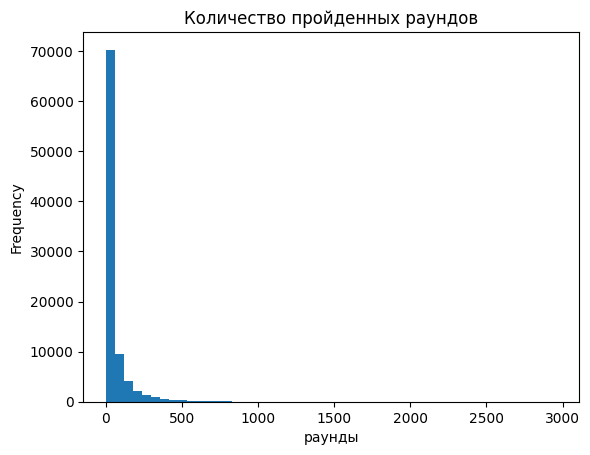

In [715]:
# для исследовательского анализа остается
# одна колонка 'sum_gamerounds', посмотрим
# на нее подробнее

display(df.sum_gamerounds.describe())

df.sum_gamerounds.plot(kind='hist', bins=50)

plt.title('Количество пройденных раундов')
plt.xlabel('раунды')

plt.show();

Абсолютное большинство игроков сыграло небольшое количество раундов. Медиана равна 16, что в данном случае более показательно чем среднее из-за длинного хвоста.

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


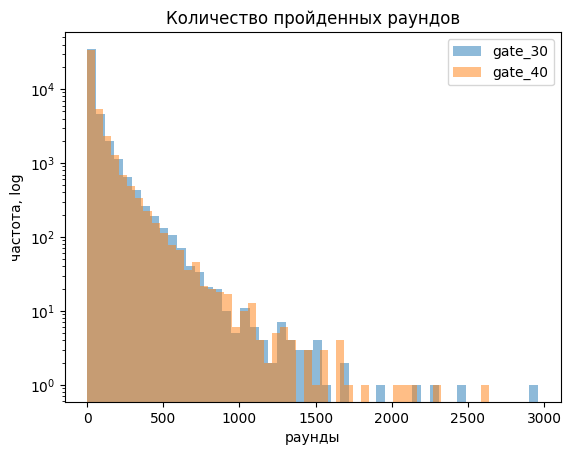

In [716]:
# посмотрим на гистограмму по группам

display(df.groupby('version').describe().sum_gamerounds)

fig, ax = plt.subplots()

bins = 50
alpha = 0.5

ax.hist(df.query('version == "gate_30"').sum_gamerounds, 
         bins=bins, 
         alpha=alpha,
         label='gate_30')

ax.hist(df.query('version == "gate_40"').sum_gamerounds,
         bins=bins,
         alpha=alpha,
         label='gate_40')

plt.yscale('log')

plt.title('Количество пройденных раундов')
plt.xlabel('раунды')
plt.ylabel('частота, log')
plt.legend()

plt.show();

По параметрам выборки у групп примерно одинаковые значения: **среднии** `51.34 против 51.3`, **среднеквадратическое отклонение** `102.1 против 103.3`, **25 квантиль** `5 против 5`. 

Заметная разница видна в значении **медианы** `17 против 16` и **75 квантиля** `50 против 52`.

Если посмотреть на график, то можно заметить меньшую частоту игроков из группы `B`(gate_40) примерно до 850 раунда. И наоборот, большую частоту после 850 раунда, что подтверждают значение медианы и 75 квантиля.

Возможно изменения в игре способствуют появления большего числа преданных игроков. 

In [694]:
# посмотрим на доли игроков
# в разных интервалах пройденных уровней

gate_30 = []
gate_40 = []

rrange = np.linspace(0, 3000, 21)

for i in tqdm(rrange):
    res = df[(df.sum_gamerounds >= i) & (df.sum_gamerounds < i+150)] \
            .version \
            .value_counts(normalize=True) \
            .to_dict()
    
    res_gate_30 = res['gate_30'] if res.get('gate_30') else 0
    res_gate_40 = res['gate_40'] if res.get('gate_40') else 0
    
    gate_30.append(res_gate_30)
    gate_40.append(res_gate_40)    

100%|██████████████████████████████████████████| 21/21 [00:00<00:00, 353.60it/s]


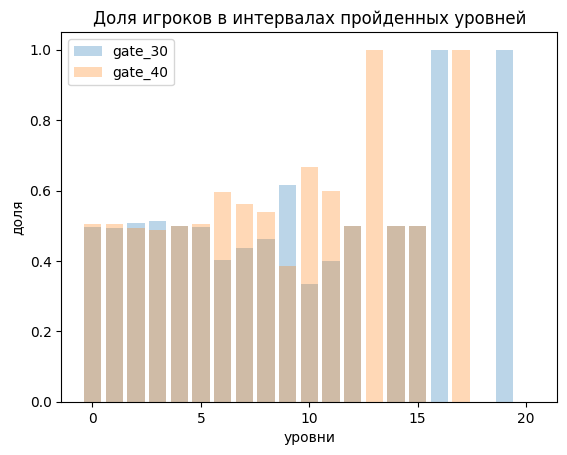

In [717]:
fir, ax = plt.subplots()

x = np.arange(len(gate_30))

plt.bar(x=x, height=gate_30, label='gate_30', alpha=0.3)
plt.bar(x=x, height=gate_40, label='gate_40', alpha=0.3)

plt.title('Доля игроков в интервалах пройденных уровней')
plt.xlabel('уровни')
plt.ylabel('доля')

plt.legend()

plt.show();

In [707]:
# после 6-й границы группа 'gate_40'
# показывает большее количество игроков,
# возьмем среднее 6 и 7 границы и
# посмотрим на количество игроков

border = (rrange[5] + rrange[6]) / 2

(
    (
        df.query('sum_gamerounds > @border')
            .version
            .value_counts()
    ),
    (
        df.query('sum_gamerounds > @border')
            .version
            .value_counts(normalize=True)
    )
)

(gate_40    108
 gate_30     88
 Name: version, dtype: int64,
 gate_40    0.55102
 gate_30    0.44898
 Name: version, dtype: float64)

В выборку попало 196 игроков. Делать выводы на основе небольшой выборки нельзя.

In [371]:
# посмотрим на метрику ретеншн 1-го и 7-го дня

df.groupby('version').mean().retention_1

version
gate_30    0.448198
gate_40    0.442283
Name: retention_1, dtype: float64

In [372]:
df.groupby('version').mean().retention_7

version
gate_30    0.190183
gate_40    0.182000
Name: retention_7, dtype: float64

### Вывод

Абсолютное большинство игроков сыграло небольшое количество раундов, медиана равна 16.

Параметры выборки по группам различаются только медианной и 75 квантилем. У группы `gate_30` медиана больше (17 против 16), у группы `gate_40` больше 75 квантиль (52 против 50). Возможно изменения в игре способствуют появления большего числа преданных игроков.

Если посчитать количество игроков по группам, которые прошли 825 или более уровней, у группы `gate_40` лучше результаты (108 против 88).

Ретеншн 1-го и 7-го дня больше у группы `gate_30` (0.448-0.442, 0.19-0.182 соответственно).

# Анализ результатов А/Б-тестирования

Для проверки гипотез о разницы двух групп, доступны 3 метрики:
* ретеншн 1-го дня
* ретеншн 7-го дня
* среднее количество пройденых уровней

Для ретеншн воспользуемся z-тестом для пропорций, для пройденых уровней воспользуемся t-тестом.

Сформируем гипотезу для ретеншн:
* H0: Между группой `gate_30` и `gate_40` метрика ретеншн не имеет значимой разницы
* H1: Между группой `gate_30` и `gate_40` метрика ретеншн имеет значимую разницу

Сформируем гипотезу для среднего количества пройденых уровней:
* H0: Между группой `gate_30` и `gate_40` среднее количество пройденых уровней не имеет значимой разницы
* H1: Между группой `gate_30` и `gate_40` среднее количество пройденых уровней имеет значимое различие

В данном случае мы будем проверять три гипотезы, и чтоб держать уровень ошибки первого рода на уровне 0.05, воспользуемся поправкой Бонферрони.

In [468]:
# поправка Бонферрони

alpha = 0.05 / 3

In [465]:
# для проверки гипотез о равенстве ретеншн,
# воспользуемся z-тестом для пропорций

def z_test_proportions(successes_1: int, successes_2: int, 
                      trials_1: int, trials_2: int,
                      alpha: float=0.05) -> None:
    
    p1 = successes_1 / trials_1
    p2 = successes_2 / trials_2
    p = (successes_1 + successes_2) / (trials_1 + trials_2)
    difference = p1 - p2
    
    z_stat = difference / np.sqrt(
        p * (1 - p) * (1/trials_1 + 1/trials_2)
    )
    
    p_value = (1 - stats.norm(0, 1).cdf(abs(z_stat))) * 2
    
    if p_value < alpha:
        print(f'p-value = {p_value:0.4f}, при alpha = {alpha:0.4f} нулевую гипотезу отвергаем')
    else:
        print(f'p-value = {p_value:0.4f}, при alpha = {alpha:0.4f} нулевую гипотезу не отвергаем')

In [470]:
gate_30_ret1_succ, gate_40_ret1_succ = df.groupby('version').sum().retention_1.array
gate_30_ret1_n, gate_40_ret1_n = df.groupby('version').count().retention_1.array

print('Retention 1-го дня:', end=' ')
z_test_proportions(gate_30_ret1_succ, gate_40_ret1_succ, 
                   gate_30_ret1_n, gate_40_ret1_n,
                   alpha)

Retention 1-го дня: p-value = 0.0739, при alpha = 0.0167 нулевую гипотезу не отвергаем


In [471]:
gate_30_ret7_succ, gate_40_ret7_succ = df.groupby('version').sum().retention_7.array
gate_30_ret7_n, gate_40_ret7_n = df.groupby('version').count().retention_7.array

print('Retention 7-го дня:', end=' ')
z_test_proportions(gate_30_ret7_succ, gate_40_ret7_succ, 
                   gate_30_ret7_n, gate_40_ret7_n,
                   alpha)

Retention 7-го дня: p-value = 0.0016, при alpha = 0.0167 нулевую гипотезу отвергаем


In [473]:
def ttest(df1: pd.DataFrame, df2: pd.DataFrame,
          alpha: float=0.05) -> None:

    m1 = df1.mean()
    m2 = df2.mean()
    var1 = df1.var()
    var2 = df2.var()
    n1 = df1.size
    n2 = df2.size
    
    t_stat = (m1 - m2) / np.sqrt(
        var1/n1 + var2/n2
    )
    df = n1 + n2 - 2
    p_value = (1 - stats.t.cdf(abs(t_stat), df=df)) * 2
    
    if p_value < alpha:
        print(f'p-value = {p_value:0.4f}, при alpha = {alpha:0.4f} нулевую гипотезу отвергаем')
    else:
        print(f'p-value = {p_value:0.4f}, при alpha = {alpha:0.4f} нулевую гипотезу не отвергаем')

In [718]:
gate_30 = df.query('version == "gate_30"').sum_gamerounds
gate_40 = df.query('version == "gate_40"').sum_gamerounds

print('Среднее количество пройденых уровней:', end=' ')
ttest(gate_30, gate_40, alpha)

Среднее количество пройденых уровней: p-value = 0.9495, при alpha = 0.5000 нулевую гипотезу не отвергаем


# 5. Выводы

На этапе обзора данных ошибок не было найдено, поэтому этап предобработки пропущен.

Ошибок в методологии проведения А/B теста не выявлено.

Из выборки была удалена одна запись с аномальным значением количества пройденных уровней.

Исследовательский анализ данных показал:
* параметры выборок отличаются только значением медианы (17 против 16) и 75 квантилем (50 против 52)
* если посчитать количество игроков по группам, которые прошли 825 или более уровней, у группы `gate_40` лучше результаты (108 против 88), но выборка небольшая и делать выводы нельзя
* ретеншн 1-го и 7-го дня больше у группы `gate_30` (0.448-0.442, 0.19-0.182 соответственно)

**Анализ результатов А/Б тестирования**

Всего было сформировано три гипотезы:
1. Между группой `gate_30` и `gate_40` метрика ретеншн 1-го дня не имеет значимой разницы
2. Между группой `gate_30` и `gate_40` метрика ретеншн 7-го дня не имеет значимой разницы
3. Между группой `gate_30` и `gate_40` среднее количество пройденых уровней не имеет значимой разницы

Результаты анализа:
1. Тест не выявил значимых различий между метрикой ретеншн 1-го дня, нулевая гипотеза не отклоняем
2. Тест показал значимые различия между метрикой ретеншн 7-го дня, нулевая гипотеза отклоняется
3. Тест не выявил значимых различий между средним количество пройденых уровней, нулевая гипотеза не отклоняем

Само тестирование было проведено корректно.